In [159]:
import numpy as np
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import copy

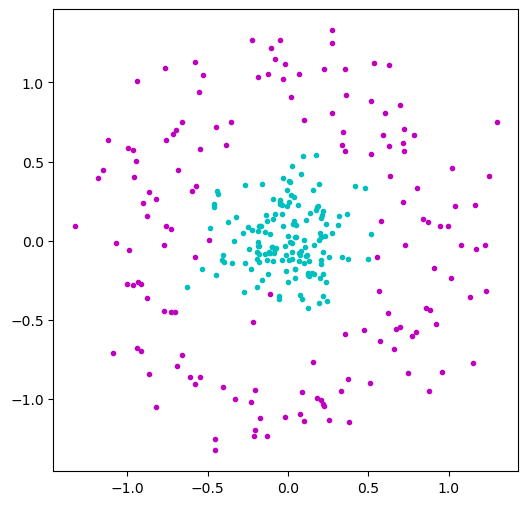

In [160]:
X,y = make_circles(n_samples = 300, noise=0.2, factor=0.1)
n,d = X.shape
plt.figure(1,figsize=[6,6])
plt.plot(X[:,0][np.where(y==1)],X[:,1][np.where(y==1)],'.c')
plt.plot(X[:,0][np.where(y==0)],X[:,1][np.where(y==0)],'.m')
plt.show()

In [161]:
def sigmoid(x):
    res = 1 / (1 + np.exp(-x))
    return res

# Exercise 1 

In [162]:
class InputUnit:
    def __init__(self,data):
        self.data = data #one column of matrix X
        self.n = data.shape[0] #dataset size
        self.k = 0 #layer number
        self.z = 0 #unit output

    def plug(self, unit):
        unit.preceding.append(self)
        unit.npr += 1

    def forward(self, index):
        x_i = self.data[index]
        self.z = x_i
        return x_i

input_unit1 = InputUnit(X[:,0])
input_unit2 = InputUnit(X[:,1])

In [163]:
class NeuralUnit:
    #Constructor
    def __init__(self,k,u):
        self.u = u #unit number
        self.preceding = [] #list of preceding neurons
        self.npr = 0 #length of list preceding
        self.following = [] #list of following neurons
        self.nfo = 0 #length of list following
        self.k = k #layer number
        self.w = 0 #unit weights
        self.b = 0 #unit intercept
        self.z = 0 #unit output
        
    def reset_params(self):
        self.w = np.random.randn(self.npr)
        self.b = np.random.randn()

    def plug(self, other_unit):
        self.following.append(other_unit)
        other_unit.preceding.append(self)

        self.nfo += 1
        other_unit.npr += 1

    def forward(self, index):
        z_in = [] 
        for u in self.preceding:
            z_in.append(u.forward(index))

        z_in = np.array(z_in)

        output = sigmoid(np.dot(self.w, z_in) + self.b)
        self.z = output
        return self.z

    def backprop(self, index, deltas):
        self.delta = np.zeros(self.w.shape) #unit gradient
        self.w_grad = np.zeros(self.w.shape)
        self.b_grad = 0

        d_sigm = self.z * (1-self.z)

        for v, unit in enumerate(self.preceding):
            
            grad_zu = d_sigm * self.w[v]
            self.delta[v] = grad_zu * deltas[self.u]

            grad_wvu = d_sigm * self.preceding[v].z
            self.w_grad[v] = grad_wvu * deltas[self.u]

        self.b_grad = d_sigm * deltas[self.u]

n1 = NeuralUnit(1, 1)
n2 = NeuralUnit(1, 2)
n3 = NeuralUnit(2, 3)

n1.following.append(n3)
n2.following.append(n3)
n3.preceding.append(n1)
n3.preceding.append(n2)

In [164]:
class Loss:
    #Constructor
    def __init__(self,y,k):
        self.preceding = [] #list of preceding neurons
        self.npr = 0 #length of list preceding
        self.y = y #array of class labels of the training data
        self.k = k #layer index

    def forward(self, index):

        zin = [] 
        for u in self.preceding:
            zin.append(u.forward(index))

        zin = np.array(zin)

        if self.y[index] == 0:
            return - np.log(1 - zin)
        else:
            return - np.log(zin)

    def backprop(self, index):

        self.delta = np.zeros((1,)) #derivative
        
        zin = self.preceding[0].z
        
        if self.y[index] == 0:
            self.delta[0] = 1 / (1 - zin)
        else:
            self.delta[0] = - (1 / zin)

In [165]:
class MLP:
    #Constructor
    def __init__(self,X,y,archi):
        self.archi = archi
        self.X = X
        self.n = X.shape[0]
        self.y = y
        self.K = len(archi) #number of layers (including input layer but omitting loss layer)
        
        #creating network
        net = []
        for l in range(self.K):

            layer = []
            for i in range(archi[l]):

                if l == 0:
                    iunit = InputUnit(X[:,i])
                    layer.append(iunit)
                        
                else:
                    n_unit = NeuralUnit(l,i)

                    for u in net[l-1]:
                        u.plug(n_unit)
                    
                    layer.append(n_unit)

            net.append(layer)
        
        self.net = net

        for layer in self.net:
            for u in layer:
                if isinstance(u, NeuralUnit):
                    u.reset_params()

        # Plug the loss
        loss = Loss(y, self.K)
        for u in net[-1]:
            u.plug(loss)

        self.net.append(loss)

    def forward(self, index):
        return self.net[-1].forward(index)

    def backprop(self, index):
       
        for k in range(self.K, 0, -1):
            if k == self.K:
                self.net[self.K].backprop(index)
                deltas = self.net[self.K].delta
            else :            
                deltas_new = np.zeros((self.net[k][0].npr,))                
                for u in range(len(self.net[k])):
                    self.net[k][u].backprop(index,deltas)
                    deltas_new += self.net[k][u].delta
                deltas = deltas_new

    def update(self, eta):

        for k in range(1,self.K):
            for unit in self.net[k]:
                unit.w = unit.w - eta * unit.w_grad
                unit.b = unit.b - eta * unit.b_grad

    def train(self, epochs,eta):
        for epoch in range(epochs):
            for i in range(self.n):
                self.forward(i)
                self.backprop(i)
                self.update(eta)

    def predict(self, index):
        return self.net[self.K-1][0].forward(index)

# Exercise 2 : Testing the forward functions

In [166]:
model = MLP(X, y, [2,2,1])

print("prediction:", model.net[-2][0].forward(10))
print("loss:", model.forward(10))
print("y[10] =", y[10])

prediction: 0.12922468779241436
loss: [0.1383713]
y[10] = 0


In [167]:
i = 0
archi = [d,10,1]
mlp = MLP(X,y,archi)
mlp.forward(i)
mlp.backprop(i)
epsi=1e-3
mlp2 = copy.deepcopy(mlp)
mlp2.net[1][0].w[0] = mlp.net[1][0].w[0] + epsi
print("numerical derivative is:",(mlp2.forward(i) - mlp.forward(i))/epsi)
print("computed derivative is:",mlp.net[1][0].w_grad[0])

numerical derivative is: [-4.86798393e-05]
computed derivative is: -4.867967864979339e-05


<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">
    The numerical derivative $\frac{\partial \ell_{i}}{\partial w^{(k)}_{v,u}}
$ and the derivative computed by backpropagation are nearly identical, which validates the correctness of the gradient computation.

# Exercice 4: Training the sample and displaying the prediction

In [168]:
mlp.train(50,0.01)

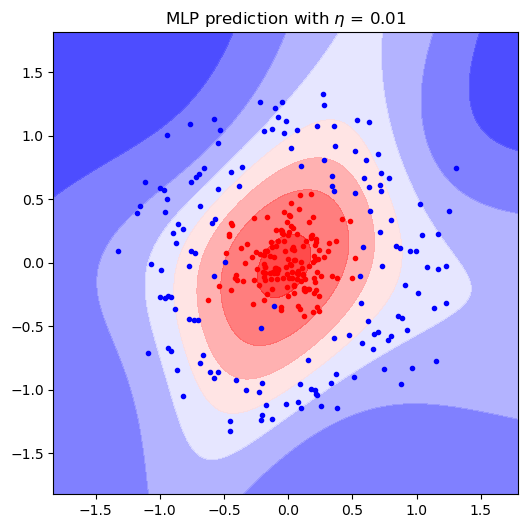

In [169]:
h = .02
x1_min, x1_max = X[:, 0].min() - .5, X[:, 0].max() + .5
x2_min, x2_max = X[:, 1].min() - .5, X[:, 1].max() + .5
x11, x22 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
X_disp = np.c_[x11.ravel(), x22.ravel()]
n_disp = X_disp.shape[0]
Z = []
for u in range(mlp.archi[0]):
    mlp.net[0][u].data = X_disp[:,u]
for i in range(n_disp):
    Z.append(mlp.predict(i))
for u in range(mlp.archi[0]):
    mlp.net[0][u].data = X[:,u]
Z = np.array(Z)
Z = Z.reshape(x11.shape)
plt.figure(2,figsize=[6,6])
plt.plot(X[:,0][np.where(y==1)],X[:,1][np.where(y==1)],'.r')
plt.plot(X[:,0][np.where(y==0)],X[:,1][np.where(y==0)],'.b')
plt.contourf(x11, x22, Z, cmap=plt.cm.bwr, alpha=.8)
plt.title(r"MLP prediction with $\eta$ = 0.01")
plt.show()

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">
    If we re-train the model, we see that the weights influence the convergence behavior. Indeed, the weights are initialized randomly which means that each time we re-run the code, we got a different initialization. 